Running stable chemical oscillation simulation...
Saved!


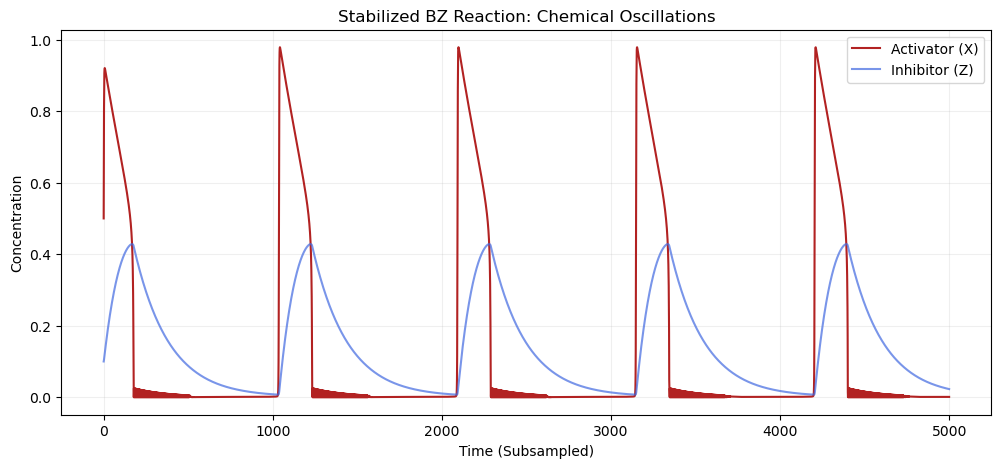

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_bz_stable(steps=50000, dt=0.001): # Smaller dt, more steps
    x, y, z = np.zeros(steps), np.zeros(steps), np.zeros(steps)
    
    # Starting concentrations (slightly adjusted for stability)
    x[0], y[0], z[0] = 0.5, 0.5, 0.1
    
    # Model parameters (classic Oregonator values)
    q = 0.0008
    f = 0.6
    epsilon = 0.01
    delta = 2.0
    
    for t in range(steps-1):
        # We use a simple Euler integration
        # Adding a small constant to the denominator to prevent division by zero
        denom = x[t] + q
        
        dx = (x[t] * (1 - x[t]) - f * z[t] * (x[t] - q) / denom) / epsilon
        dy = x[t] - y[t]
        dz = (x[t] - z[t]) / delta
        
        x[t+1] = x[t] + dx * dt
        y[t+1] = y[t] + dy * dt
        z[t+1] = z[t] + dz * dt
        
        # Physical constraint: Concentrations cannot be negative
        x[t+1] = max(x[t+1], 1e-10)
        
    return x, y, z

# Run the stabilized version
print("Running stable chemical oscillation simulation...")
x, y, z = simulate_bz_stable()

# Plotting
plt.figure(figsize=(12, 5))
plt.plot(x[::10], label='Activator (X)', color='firebrick', lw=1.5) # Subsample for clarity
plt.plot(z[::10], label='Inhibitor (Z)', color='royalblue', lw=1.5, alpha=0.7)
plt.title("Stabilized BZ Reaction: Chemical Oscillations")
plt.xlabel("Time (Subsampled)")
plt.ylabel("Concentration")
plt.legend()
plt.grid(True, alpha=0.2)
plt.savefig('belousov-zhabotinsky_reaction_test.png')
print("Saved!")